In this notebook, we will explore the basics of unsupervised learning, a type of machine learning that deals with unlabeled data. Unlike supervised learning, where the  model is trained on labeled data, unsupervised learning algorithms try to find patterns and relationships in the data without any prior knowledge of the outcomes. We will cover here two different applications: clustering and dimensionality reduction.

# Clustering

Clustering refers to the task of grouping data points into coherent categories without using labels. The goal is to assign samples to clusters such that points within the same group are similar to each other while being dissimilar to points in other groups. We will review here the most popular clustering algorithm, *k-means*, although many others exists, such as *Gaussian Mixture Models (GMMs)*, *DBSCAN*, or *hierarchical clustering*.

## k-means
*k-means* is an iterative clustering algorithm that partitions a dataset into $k$ clusters by minimizing the total within-cluster variance.  Given data points $\{x_1, \dots, x_N\} \subset \mathbb{R}^d$, the objective is to find cluster assignments and centroids $\{\mu_1, \dots, \mu_k\}$ that minimize

\begin{equation}
\mathcal{L} = \sum_{i=1}^N \left\| x_i - \mu_{c(i)} \right\|^2 ,
\end{equation}

where $c(i)$ denotes the index of the cluster assigned to point $x_i$.

The algorithm alternates between two steps:

1. Assignment step: Assign each point to the nearest centroid,
\begin{equation}
c(i) = \arg\min_{j = 1,\dots, k} \left\| x_i - \mu_j \right\|^2 .
\end{equation}

2. Update step: Recompute each centroid as the mean of its assigned points,
\begin{equation}
\mu_j = \frac{1}{|\{i : c(i) = j\}|} 
\sum_{i : c(i) = j} x_i .
\end{equation}

These steps are repeated until convergence, typically when assignments no longer change or the loss decreases negligibly.

*k-means* is computationally efficient and performs well when clusters are roughly spherical, similarly sized, and well separated. However, it is sensitive to initialization, cannot capture complex cluster shapes, and provides no probabilistic interpretation. It is therefore mainly used as a baseline clustering method or as preprocessing in more advanced unsupervised workflows.

To implement it, we can use the `KMeans` class from the `sklearn.cluster` module. Here's an example of how to use it:

Text(0.5, 1.0, 'k-means clustering with sklearn')

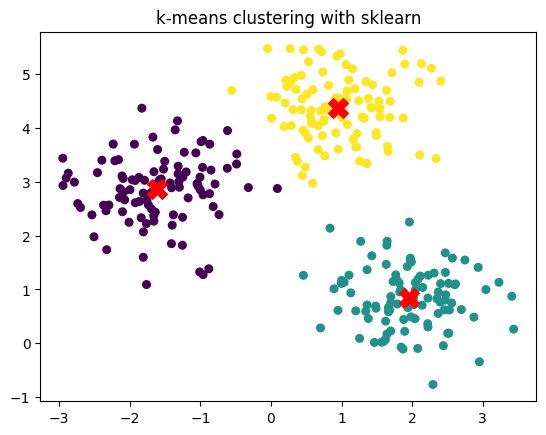

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate synthetic 2D data
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Fit k-means with k = 3
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

# Predicted cluster labels
y_pred = kmeans.labels_

# Cluster centers
centers = kmeans.cluster_centers_

# Plot
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
plt.title("k-means clustering with sklearn")

# Dimensionality reduction

Dimensionality reduction aims to represent high-dimensional data in a lower-dimensional space while preserving as much of its relevant structure as possible. Many real-world datasets—images, trajectories, physical states—lie near a low-dimensional manifold embedded in a high-dimensional space, making it inefficient or unstable to work directly in the original representation. Reducing dimensionality allows us to compress data, visualize complex structures, remove noise, and simplify downstream tasks. 

Classical methods such as PCA provide a linear projection that captures directions of maximal variance, giving a simple and interpretable baseline. However, many datasets exhibit nonlinear relationships that linear methods cannot capture. In such cases, neural network–based approaches like autoencoders offer a flexible framework for learning nonlinear low-dimensional embeddings through an encoder–decoder architecture.

This section introduces both perspectives: first, PCA as a principled linear method, and then autoencoders as a nonlinear generalization capable of learning richer, data-adapted latent spaces.

## Principal Component Analysis (PCA)

> You can find a more in depth introduction to PCA in this [notebook](https://borjarequena.github.io/Machine-Learning-Course/course/classical_ml/pca.html) from B. Requena, fro mwhich this section is inspired.

Principal Component Analysis (PCA) is a classical method for linear dimensionality reduction that seeks a low-dimensional representation of the data while preserving as much variance as possible.  Given centered data points $\{x_1, \dots, x_n\}$, with $x \in \mathbb{R}^d$, PCA looks for an orthonormal set of directions, onto which the projection of the data maximizes total variance. To do so, we start by computing the data matrix $X \in \mathbb{R}^{n \times d}$, where each row corresponds to a data point. We then compute the covariance as

\begin{equation}
C = \frac{1}{n} (X - \bar{X})^\top (X - \bar{X}) 
\end{equation}
where $\bar{X}$ is the mean of the dataset. In practice, we rather consider the centered data matrix $X_c = X - \bar{X}$, where now every feature has mean zero. 
The covariance matrix is a $d\times d$ symmetric matrix where every entry $C_{ij}$ represents the covariance between features $i$ and $j$.
Therefore, we have the variance of each feature in the diagonal ($C_{ii}$ terms).

The eigendecomposition of this matrix into its eigenvalues $\{\lambda_i\}$ and eigenvectors $\{\mathbf{v}_i\}$, provides us with the directions along which the data varies the most, i. e., the principal components (PCs).
The variance captured by each PC is proportional to its eigenvalue, which allows us to rank them according to the information they provide.

Importantly, PCA offers an interpretable and computationally efficient way to reduce dimensionality, but it is limited to *linear* transformations. Nonetheless, is a very useful technique for many datasets, as we will see next, and typically serves as a good embedding for more complex tasks. Other nonlinear dimensionality reduction techniques include t-SNE, UMAP, and autoencoders, which we will explore next.

Let's illustrate PCA with a simple example using `sklearn`. We will generate a nonlinear 3D dataset (the Swiss roll) and apply PCA to reduce its dimensionality from 3D to 2D.

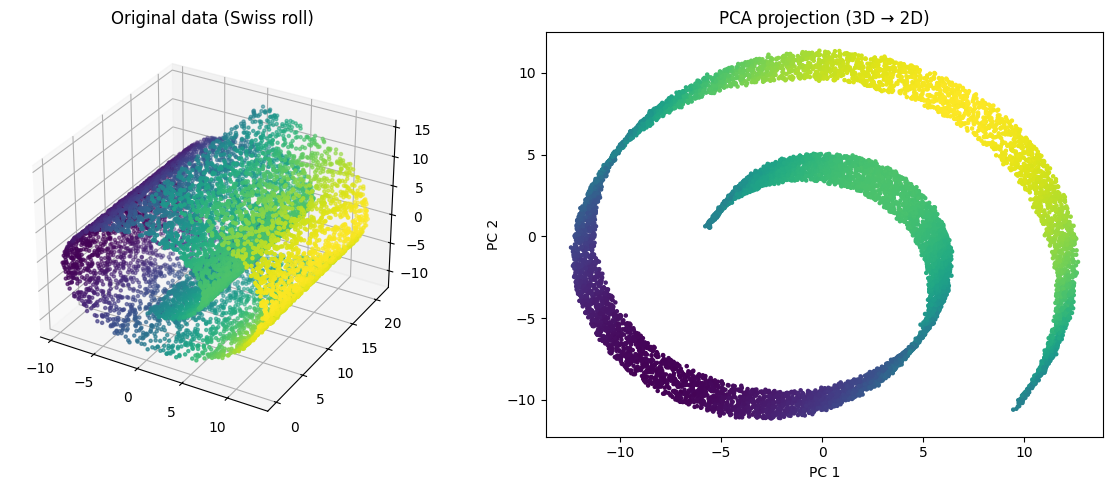

In [34]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import make_swiss_roll

# Generate a nonlinear 3D dataset (Swiss roll)
X, _ = make_swiss_roll(n_samples=10000, noise=0.05)

# Apply PCA to reduce 3D → 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot original data (3D)
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X[:, 0], cmap='viridis', s=5)
ax.set_title("Original data (Swiss roll)")

# Plot PCA projection
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X[:, 0], cmap='viridis', s=5)
plt.title("PCA projection (3D → 2D)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")

plt.tight_layout()
plt.show()


While PCA may seem like a very simple technique, it is already quite useful for simple datasets, as for instance the Ising configurations we use in HW 1:

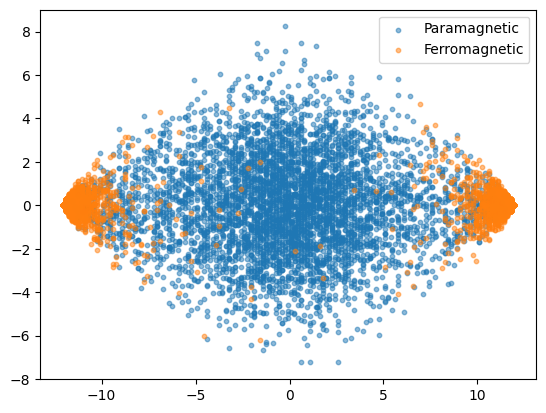

In [3]:
import torch

path_to_data = '' # Choose your path 

configs = torch.load(path_to_data+'input_data.pt').flatten(1,2)
trues = torch.load(path_to_data+'trues.pt')

pca = PCA(n_components=2)
ising_pca = pca.fit_transform(configs)

plt.scatter(ising_pca[trues == 0, 0], ising_pca[trues == 0, 1],
            s=10, alpha = 0.5, label='Paramagnetic')

plt.scatter(ising_pca[trues == 1, 0], ising_pca[trues == 1, 1],
            s=10, alpha = 0.5, label='Ferromagnetic')
plt.legend()

## Autoencoders

Linear methods like PCA provide a simple way to reduce dimensionality, but they can only capture structure that lies close to a flat, linear subspace. Many real datasets—such as images, trajectories, or physical configurations—lie on highly curved or multimodal manifolds that PCA cannot represent without distorting their geometry. This makes PCA insufficient whenever the underlying relationships in the data are nonlinear.

Autoencoders address this limitation by learning a nonlinear mapping from the data to a lower-dimensional latent space and back (see original proposal by [Hinton et al.](https://www.science.org/doi/full/10.1126/science.1127647)). An autoencoder consists of two neural networks: an **encoder** that projects the input into the **latent space**, and a decoder that reconstructs the original data from this. The network is trained to minimize the reconstruction error, with the key addition that the dimension of the latent space is usually much lower that the dimension of the data. That encourages the latent representation to capture the most salient features of the data.

::: {#fig-mdp}
<img src="../../figures/ae.svg" width="30%"/>

Schematic representation of an autoencoder.
:::


In particular, given a data $D = \{x_1, \dots, x_N\}$ with $x_i \in \mathbb{R}^d$, the AE is trained via the reconstruction error, typically defined by means of the MSE:

\begin{equation}
\mathcal{L} = \frac{1}{N} \sum_{i=1}^N \left\| x_i - \hat{x}_i \right\|^2 ,
\end{equation}
where $\hat{x}_i = \text{decoder}(\text{encoder}(x_i))$ is the reconstructed input.

Let's implement a simple autoencoder using PyTorch and apply it to the Ising configurations. Of course, we can choose the encoder and decoder to be whatever we want! Here, we will use a convolutional architecture, as we know they work well for this dataset.



In [21]:
#| code-fold : true
#| code-summary : AE architecture
import torch
import torch.nn as nn

class Conv_AE(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()
        
        # ----- Encoder: 1x12x12 → 8x6x6 → 16x3x3 -----
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),   # -> 8 x 6 x 6
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),  # -> 16 x 3 x 3
            nn.ReLU()
        )
        
        self.flat_dim = 16 * 3 * 3  
        
        # Linear bottleneck
        self.encoder_fc = nn.Linear(self.flat_dim, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, self.flat_dim)

        # ----- Decoder: 16x3x3 ← 8x6x6 ← 1x12x12 -----
        self.decoder_cnn = nn.Sequential(
            # 16x3x3 -> 8x6x6
            nn.ConvTranspose2d(
                in_channels=16, out_channels=8,
                kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            # 8x6x6 -> 1x12x12
            nn.ConvTranspose2d(
                in_channels=8, out_channels=1,
                kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_cnn(x)                    # (B, 16, 3, 3)
        h = h.view(x.size(0), -1)                  # (B, 144)
        z = self.encoder_fc(h)                     # (B, latent_dim)
        return z

    def decode(self, z):
        h = self.decoder_fc(z)                     # (B, 144)
        h = h.view(z.size(0), 16, 3, 3)            # (B, 16, 3, 3)
        x_hat = self.decoder_cnn(h)                # (B, 1, 12, 12)
        return x_hat

    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out

In [22]:
#| code-fold : true
#| code-summary : Data loading

configs_dataset = torch.load(path_to_data+'input_data.pt').to(torch.float).unsqueeze(1)
labels_dataset = torch.load(path_to_data+'trues.pt')
ratio = int(0.8*configs_dataset.shape[0])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
X_a = configs_dataset[:ratio].to(device)
X_e = configs_dataset[ratio:].to(device)

Y_a = labels_dataset[:ratio]
Y_e = labels_dataset[ratio:]

from torch.utils.data import TensorDataset

# Create Dataset. Note that Input and Output are the SAME!
train_data = TensorDataset(X_a, X_a)
eval_data = TensorDataset(X_e, X_e)


batch_size = 1000

# Create DataLoaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(eval_data, batch_size=batch_size, shuffle=False)

In this example I will use a different way of training through a highlevel library: [FastAI](https://docs.fast.ai/). This library allows you to bundle your training loops, and use different features that will ease your ML trainings. Another great option for this is [PyTorch Lightning](https://pytorch-lighting.readthedocs.io/en/latest/), which you can also explore.

In [25]:
#| output: false

# First you need to install fastai via pip: pip install fastai

# For this example we will need three imports
from fastai.vision.all import Learner, Adam, DataLoaders

# We then put together both train and validations dataloaders
data = DataLoaders(train_loader, val_loader)

# Then we create a Learner object, which bundles together the data, model, loss function and optimizer
learner = Learner(data, Conv_AE(latent_dim=2), loss_func=nn.MSELoss(), opt_func=Adam)

# Finally we train the model using
learner.fit(50, lr = 1e-3)

epoch,train_loss,valid_loss,time
0,1.225806,1.247522,00:00
1,1.222433,1.241545,00:00
2,1.219278,1.235423,00:00
3,1.215646,1.228068,00:00
4,1.211346,1.217196,00:00
5,1.205254,1.196478,00:00
6,1.194596,1.153722,00:00
7,1.175855,1.084271,00:00
8,1.147373,1.002914,00:00
9,1.111258,0.930517,00:00


`fastai` will save in the learner the model, as well as some training statistics. We can access them as follows:

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

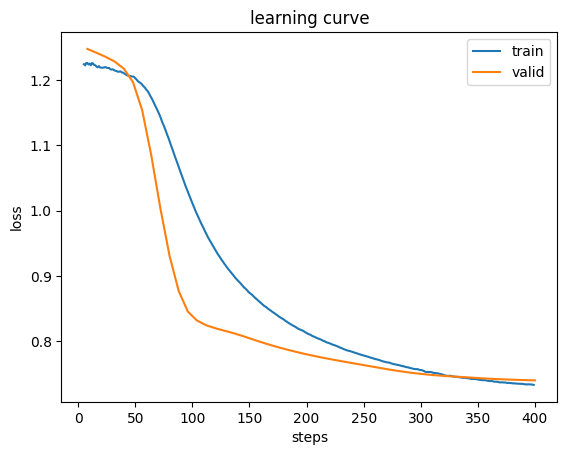

In [26]:
learner.recorder.plot_loss()

Now let's look into the latent space of the trained AE. We can access that as follows:

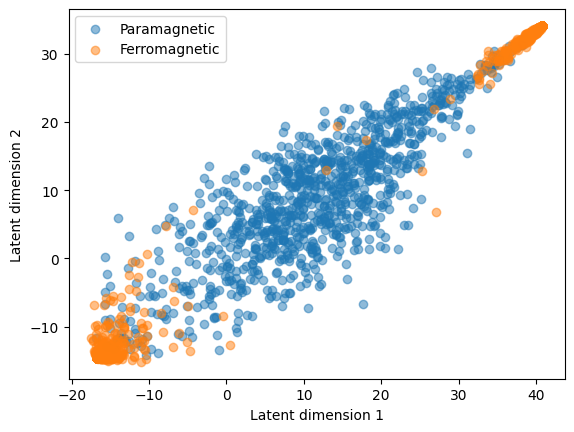

In [27]:
latent = learner.model.encode(X_e)

# Let's put everything in the CPU (if you trained in GPU) to ease plotting
latent = latent.cpu().detach().numpy()

# And plot
plt.scatter(latent[Y_e == 0, 0], latent[Y_e == 0, 1],
            alpha = 0.5, label='Paramagnetic')

plt.scatter(latent[Y_e == 1, 0], latent[Y_e == 1, 1],
            alpha = 0.5, label='Ferromagnetic')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')
plt.legend()

As you can see, the AE has learned a representation that again separates both phases quite well, kind of on the same level as the PCA. Now that we have this nice learned distribution, we can for instance use a *k-means* clustering and see if we would be able to actually classify these two phases. We will consider here a LOT of assumptions and prior knowledge, as for instance that there are 2 phases, and that that the ferromagnetic has two opposite blobs. Nonetheless, we could inspect the configurations and see that one blob contains configurations with positive magnetization, and the other with negative magnetization.

Text(0.5, 1.0, 'k-means clustering with sklearn')

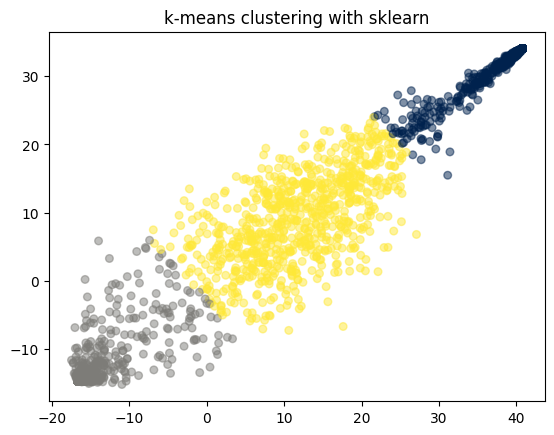

In [28]:
# We now consider here 3 clusters (because of the two blobs of ferromagnetic)
kmeans = KMeans(n_clusters = 3, random_state=0)
kmeans.fit(latent)

# Predicted cluster labels
y_pred = kmeans.labels_

# Cluster centers
centers = kmeans.cluster_centers_

# Plot
plt.scatter(latent[:, 0], latent[:, 1], c=y_pred, s=30, cmap='cividis', alpha = 0.5)
plt.title("k-means clustering with sklearn")

As we can see, *k-means* does an okay job. Let's quantify it with the accuracy score:

In [29]:
# We change the labels to match the true labels and be able to compute accuracy
# This adaption may need to be changed depending on the results of k-means!
y_pred_adjusted = y_pred.copy()
y_pred_adjusted[(y_pred_adjusted == 0) | (y_pred_adjusted == 1)] = 3
y_pred_adjusted -= 2

# And now we compute the accuracy
np.mean(y_pred_adjusted == Y_e.numpy())

np.float64(0.882)

As you can see, we end up having a very decent accuracy, not that bad at all for a "completely" unsupervised approach!

::: {.callout-tip}

## Exercise - Denoising with AE

AE can also be used for many different purposes. A common one is denoising. The idea is to train the AE to reconstruct clean images from noisy ones. This can be done by adding noise to the input images during training, and using the original clean images as targets. The AE learns to remove the noise and recover the underlying structure of the data. Another common application is colouring, where the input image is black and white and the output is the colored one. 

For this task, let's consider a simple purely convolutional AE:

In [13]:
class Full_Conv_AE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 1x28x28 -> 16x14x14 -> 32x7x7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # -> 16x14x14
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> 32x7x7
            nn.ReLU(True)
        )
        # Decoder: 32x7x7 -> 16x14x14 -> 1x28x28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # -> 16x14x14
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # -> 1x28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

Now you can use the following function to noise the *input* images. For instance, one can use:

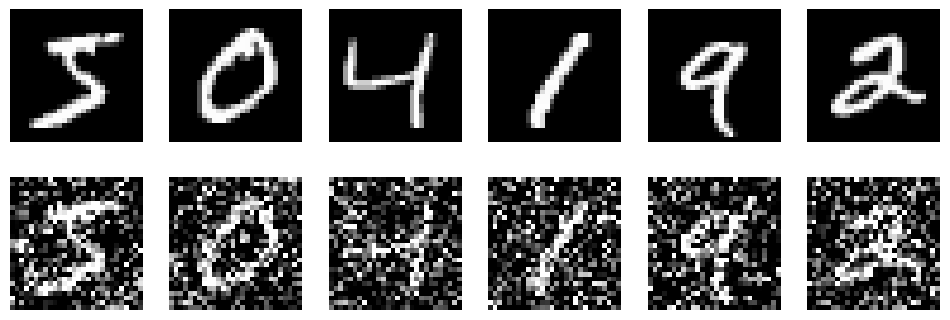

In [15]:
from torchvision import datasets, transforms

def add_noise(x, noise_factor=0.5):
    x_noisy = x + noise_factor * torch.randn_like(x)
    return torch.clip(x_noisy, 0., 1.)

train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor()).data.to(torch.float).unsqueeze(1)/255
test_dataset  = datasets.MNIST(root="data", train=False, download=True, transform=transforms.ToTensor()).data.to(torch.float).unsqueeze(1)/255

in_a = add_noise(train_dataset)
out_a = train_dataset

in_e = add_noise(test_dataset)
out_e = test_dataset

fig, axs = plt.subplots(2,6, figsize=(12,4))
for noisy_img, img, ax in zip(in_a, out_a, axs.transpose()):
    ax[0].imshow(img.squeeze(0), cmap="gray")
    ax[1].imshow(noisy_img.squeeze(0), cmap="gray")
    for a in ax: a.set_axis_off()
    

Use this to create the data and then train the AE to denoise images. At the end of the training, visualize the denoised images for the validation dataset, comparing them to the original, clean ones. 
:::

In [16]:
#| code-fold : true
#| code-summary: Solution - Dataloaders

# Create Dataset. Note that Input and Output are the SAME!
train_data = TensorDataset(in_a, out_a)
eval_data = TensorDataset(in_e, out_e)

batch_size = 128

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(eval_data, batch_size=batch_size, shuffle=False)

In [17]:
#| code-fold : true
#| code-summary: Solution - Training with FastAI

data = DataLoaders(train_loader, val_loader)

# Then we create a Learner object, which bundles together the data, model, loss function and optimizer
learner = Learner(data, Full_Conv_AE(), loss_func=nn.MSELoss(), opt_func=Adam)

# Finally we train the model using
learner.fit(5, lr = 1e-3)

epoch,train_loss,valid_loss,time
0,0.017291,0.016135,00:01
1,0.014738,0.014445,00:01
2,0.014119,0.013921,00:02
3,0.013770,0.013596,00:01
4,0.013510,0.013427,00:02


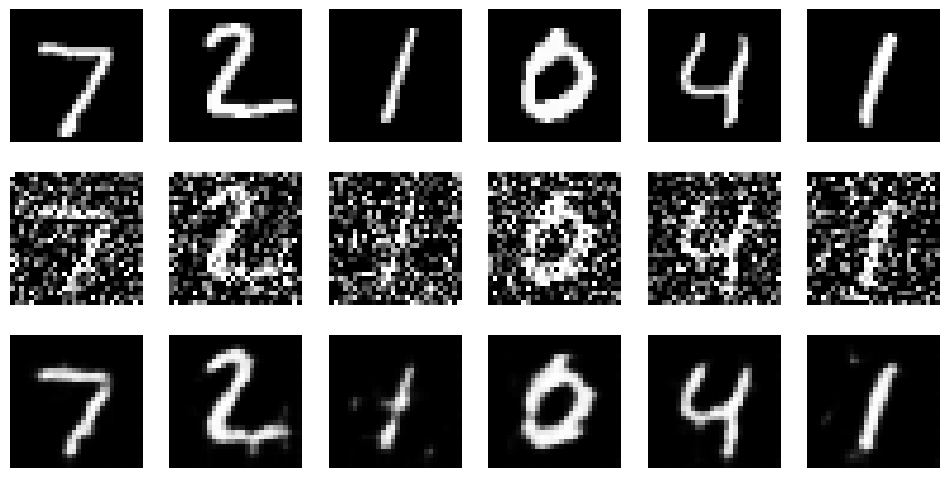

In [19]:
#| code-fold : true
#| code-summary: Solution - Plotting
learner.model.eval()

noisy, originals = next(iter(val_loader))

denoised = learner.model(noisy.to(device)).detach().cpu()    

fig, axs = plt.subplots(3,6, figsize=(12,6))
for o, n, d, ax in zip(originals, noisy, denoised, axs.transpose()):

    ax[0].imshow(o.squeeze(0), cmap="gray")
    ax[1].imshow(n.squeeze(0), cmap="gray")    
    ax[2].imshow(d.squeeze(0), cmap="gray")
    for a in ax: a.set_axis_off()